# Business Problem

Customer churn represents a critical challenge for subscription-based businesses, as losing customers directly impacts revenue stability and long-term growth. Understanding why customers leave and identifying early indicators of churn are essential for improving retention strategies and protecting the economic value of the customer base.

This analysis aims to investigate the drivers of customer churn within a subscription platform by examining customer behavior, contract structures, and revenue patterns. In particular, the analysis seeks to identify which customer segments are most vulnerable to churn, which operational and behavioral factors are most strongly associated with customer attrition, and how churn affects overall revenue generation.

By combining exploratory analysis, revenue segmentation, and predictive modeling techniques, this project aims to generate actionable insights that can support data-driven strategies to reduce churn and improve revenue stability.


# Data Exploration

In [3]:
import pandas as pd

# Colunm exploration

df = pd.read_csv("customer_churn_dataset-training-master.csv")
display(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


None

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


# Data Cleaning

Observations from the initial dataset inspection:

The dataset contains 440,832 observations and 12 variables.

There are no missing values across any of the columns.

Column names are clear and interpretable, facilitating business-oriented analysis.

Categorical variables such as Gender, Subscription Type, and Contract Length are correctly stored as object data types.

During the inspection, several numerical variables representing counts or discrete values (e.g., Age, Tenure, Usage Frequency, Support Calls, Payment Delay, Last Interaction, and Churn) were initially stored as float64. Since these variables represent integer-based measures, they were converted to integer format to improve data consistency and better reflect their semantic meaning.

Before performing these transformations, a backup copy of the original dataset was created to preserve the raw data and ensure reproducibility of the analysis.

The cleaned dataset (df_clean) will be used for all subsequent analyses.

In [4]:
# Backup data

df_clean = df.copy()

# Columns that should be integers
int_columns = [
    "CustomerID",
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Last Interaction",
    "Churn"
]

# Check NaN
df_clean[int_columns].isna().sum()
df_clean[df_clean[int_columns].isna().any(axis=1)]

# Remove rows with missing values
df_clean = df_clean.dropna()

# Convert variables to integer
df_clean[int_columns] = df_clean[int_columns].astype(int)

# Check for duplicates 
display(df_clean.duplicated().sum())
display(df_clean.duplicated().sum())

df_clean.info()


np.int64(0)

np.int64(0)

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  int64  
 1   Age                440832 non-null  int64  
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  int64  
 4   Usage Frequency    440832 non-null  int64  
 5   Support Calls      440832 non-null  int64  
 6   Payment Delay      440832 non-null  int64  
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  int64  
 11  Churn              440832 non-null  int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 43.7+ MB


## Handling Missing Values

Although the initial dataset inspection suggested no missing values, further validation revealed a small number of missing entries across several numerical columns.

Since these missing values appeared in only one observation out of more than 440,000 records, the decision was made to remove the affected row to preserve data integrity without introducing artificial values.

This approach ensures that the dataset remains clean while avoiding unrealistic imputations.

## Duplicate Records Validation

The dataset was validated for duplicate observations both at the row level and at the customer identifier level.

No duplicate rows were detected, and each CustomerID appears only once, confirming that every record corresponds to a unique customer observation.

# Customer Segmentation Analysis

Before analyzing revenue dynamics in detail, it is essential to understand how customers are distributed across key segments and how these segments differ in terms of churn behavior and engagement.

Customer segmentation helps identify which groups of users contribute the most value to the platform and which segments may present higher retention risks.

This section explores segmentation patterns based on subscription type, contract length, and customer tenure, providing an initial view of how different customer groups behave within the platform.

## Churn Rate by Subscription Type

In [5]:
import duckdb
import pandas as pd

In [6]:
# Mean from churn rate with SQL
churn_subscription = duckdb.sql("""
    SELECT
        "Subscription Type",
        AVG(Churn) AS churn_rate
    FROM df_clean
    GROUP BY "Subscription Type"
    ORDER BY churn_rate DESC
""").df()

churn_subscription

,Subscription Type,churn_rate
0,Basic,0.581782
1,Standard,0.560700
2,Premium,0.559417


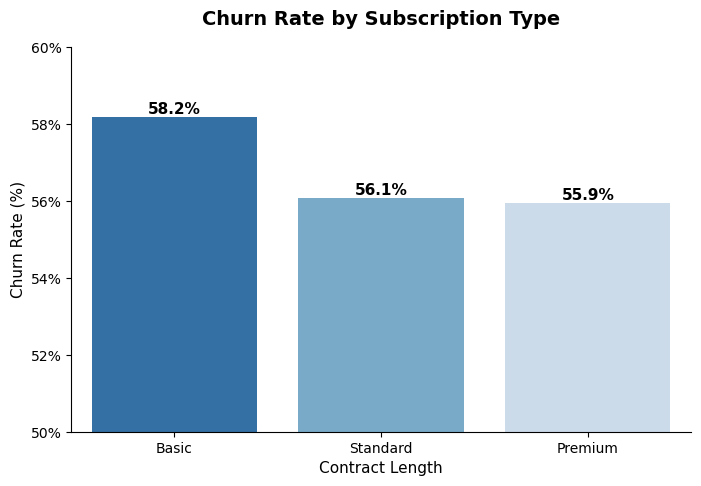

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=churn_subscription,
    x="Subscription Type",
    y="churn_rate",
    hue="Subscription Type",
    palette="Blues_r",
    legend=False
)

# Format Y axis as percentage starting from 0
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
# Convert axe to percentage 
plt.ylim(0.50, 0.60)

plt.title("Churn Rate by Subscription Type", fontsize=14, fontweight="bold", pad=16)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.xlabel("Contract Length", fontsize=11)
sns.despine()

# Add percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.001,
        f'{height:.1%}',
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.show()

Churn rates appear relatively high across all subscription tiers, ranging from approximately 56% to 58%.
Basic plans show slightly higher churn compared to Standard and Premium tiers, though the differences between segments are relatively small.

## Churn Rate by Contract Length

In addition to subscription tiers, contract structure can play a significant role in shaping revenue patterns. Different contract lengths may influence both customer commitment and spending behavior.

To further understand the economic contribution of each contract segment, the following analysis examines how total revenue and average revenue per customer vary across contract lengths. This helps identify whether longer commitments are associated with higher revenue generation or whether revenue is evenly distributed across contract structures.

In [8]:
# Calculate churn_rate 
churn_by_contract = duckdb.sql("""
    SELECT
        "Contract Length",
        AVG(Churn) AS churn_rate
    FROM df_clean
    GROUP BY "Contract Length"
    ORDER BY churn_rate DESC
""").df()

churn_by_contract

,Contract Length,churn_rate
0,Monthly,1.000000
1,Annual,0.460761
2,Quarterly,0.460256


In [9]:
duckdb.sql("""
SELECT
    "Contract Length",
    COUNT(*) AS customers,
    SUM(Churn) AS churned
FROM df_clean
GROUP BY "Contract Length"
""").df()

,Contract Length,customers,churned
0,Quarterly,176530,81249.0
1,Annual,177198,81646.0
2,Monthly,87104,87104.0


In [10]:
df_clean["Churn"].value_counts()

Churn
1    249999
0    190833
Name: count, dtype: int64

### Validation of Churn Rate by Contract Length

During the initial analysis, the churn rate by contract length revealed an unexpected result: customers with monthly contracts showed a churn rate of 100%. Since this outcome appeared unusually high for a real-world subscription business, the metric was further investigated to validate the calculation.

To verify the result, the distribution of customers and churned users was examined using SQL. By aggregating the total number of customers and the number of churned users by contract length, it was confirmed that all customers with monthly contracts in the dataset were labeled as churned. This explains why the average churn rate for the monthly segment equals 1.0.

This validation step ensured that the result was not caused by a calculation error but rather reflects the structure of the dataset.

In [11]:
duckdb.sql("""
SELECT
    "Subscription Type",
    "Contract Length",
    COUNT(*) AS customers,
    AVG(Churn) AS churn_rate
FROM df_clean
GROUP BY
    "Subscription Type",
    "Contract Length"
ORDER BY churn_rate DESC
""").df()

,Subscription Type,Contract Length,customers,churn_rate
0,Standard,Monthly,28985,1.000000
1,Basic,Monthly,29050,1.000000
2,Premium,Monthly,29069,1.000000
3,Basic,Quarterly,56621,0.475884
4,Basic,Annual,57355,0.474501
5,Standard,Quarterly,60128,0.454979
6,Standard,Annual,60015,0.454453
7,Premium,Annual,59828,0.453918
8,Premium,Quarterly,59781,0.450762


### Segment-Level Churn Analysis

After validating the churn distribution across contract types, a more granular segmentation was performed by analyzing churn across both subscription type and contract length.

This double segmentation allows us to better understand how different combinations of subscription plans and contractual commitments relate to customer churn. Such segmentation is commonly used in subscription-based businesses to identify high-risk customer segments and design targeted retention strategies.

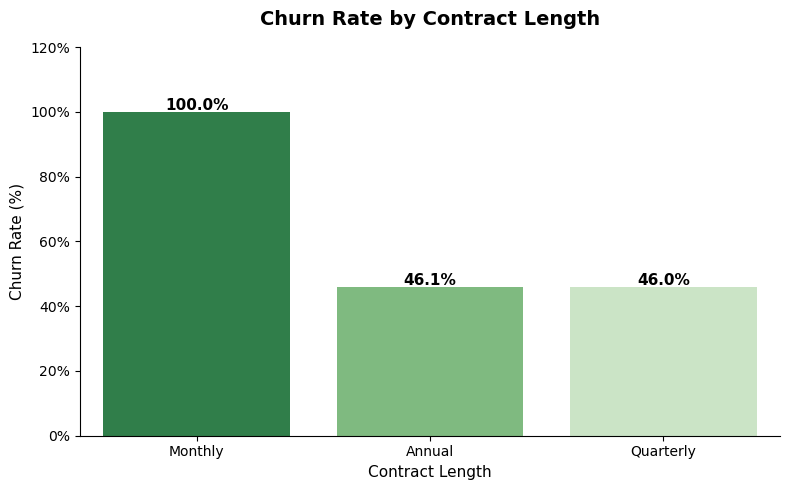

In [35]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=churn_by_contract,
    x="Contract Length",
    y="churn_rate",
    hue="Contract Length",
    palette="Greens_r",
    legend=False
)

# Format Y axis as percentage starting from 0
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
plt.ylim(0, churn_by_contract["churn_rate"].max() * 1.2)

plt.title("Churn Rate by Contract Length", fontsize=14, fontweight="bold", pad=16)
plt.ylabel("Churn Rate (%)", fontsize=11)
plt.xlabel("Contract Length", fontsize=11)
sns.despine()

# Add percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.005,
        f'{height:.1%}',
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("churn_by_contract.png",dpi=300,bbox_inches="tight")
plt.savefig("churn_by_contract_p.png",dpi=300,bbox_inches="tight", transparent=True)
plt.show()

Customers on monthly contracts exhibit a significantly higher churn rate compared with longer contract commitments. In this dataset, all monthly subscribers churned, suggesting that short-term contracts are associated with extremely low customer retention.

The dataset shows a strong relationship between contract length and churn probability.

## Customer Tenure vs Churn

In [13]:
duckdb.sql("""
SELECT
    Churn,
    COUNT(*) AS customers,
    AVG(Tenure) AS avg_tenure,
    MEDIAN(Tenure) AS median_tenure,
    STDDEV(Tenure) AS std_tenure
FROM df_clean
GROUP BY Churn
""").df()

,Churn,customers,avg_tenure,median_tenure,std_tenure
0,0,190833,32.281754,33.0,17.089172
1,1,249999,30.473598,30.0,17.341065


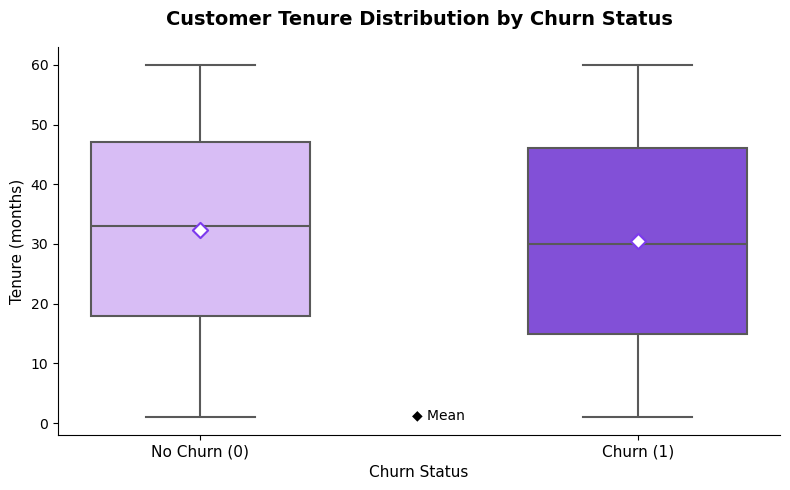

In [14]:
from matplotlib.ticker import PercentFormatter
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 5))

# Boxplot in purple palette
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="Tenure",
    hue="Churn",
    palette={0: "#d8b4fe", 1: "#7c3aed"},
    width=0.5,
    linewidth=1.5,
    flierprops=dict(marker="o", markerfacecolor="#7c3aed", markersize=4, alpha=0.4),
    legend=False,
    ax=ax
)

# Add mean as a red diamond on each box
means = df_clean.groupby("Churn")["Tenure"].mean()
for i, (churn_val, mean_val) in enumerate(means.items()):
    ax.scatter(i, mean_val, marker="D", color="white", s=60, zorder=5, linewidths=1.5, edgecolors="#7c3aed")

# Style
ax.set_title("Customer Tenure Distribution by Churn Status", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Churn Status", fontsize=11)
ax.set_ylabel("Tenure (months)", fontsize=11)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Churn (0)", "Churn (1)"], fontsize=11)
sns.despine()

# Legend for mean marker
mean_marker = mpatches.Patch(color="white", label="◆ Mean")
ax.legend(handles=[mean_marker], frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

The distribution of customer tenure is very similar between churned and retained users. Both groups show comparable medians and ranges, suggesting that tenure alone is not a strong predictor of churn in this dataset. This contrasts with many real-world subscription businesses where newer customers tend to churn more frequently. In this dataset, churn appears to be more strongly associated with contract structure rather than customer tenure.

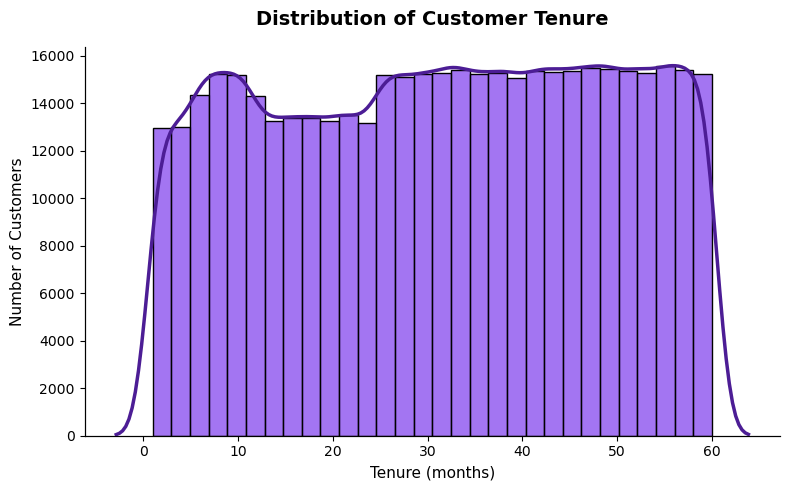

In [15]:
from scipy import stats

fig, ax = plt.subplots(figsize=(8, 5))

# Histogram in purple
sns.histplot(
    data=df_clean,
    x="Tenure",
    bins=30,
    color="#7c3aed",
    alpha=0.7,
    ax=ax
)

# KDE trend line on separate axis
ax2 = ax.twinx()
sns.kdeplot(
    data=df_clean,
    x="Tenure",
    color="#4c1d95",
    linewidth=2.5,
    ax=ax2
)

# Hide right axis
ax2.set_ylabel("")
ax2.set_yticks([])

# Style
ax.set_title("Distribution of Customer Tenure", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Tenure (months)", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)
sns.despine(right=True)

plt.tight_layout()
plt.show()

The distribution of customer tenure appears relatively uniform across the observed range (1–60). Unlike typical subscription datasets where newer customers tend to be more common, this dataset shows a nearly even distribution of tenure values. This suggests that tenure may have been synthetically generated or randomly distributed, which helps explain why tenure does not strongly differentiate churn behavior in the analysis.

# Revenue Analysis

After completing the initial data inspection and cleaning process, the dataset is now considered structurally consistent and ready for analysis. The cleaned dataset (`df_clean`) will be used for all subsequent calculations and exploratory analysis.

The preliminary segmentation analysis revealed several structural patterns within the customer base. In particular, contract length shows a strong association with churn behavior, with monthly contracts displaying substantially higher churn rates compared with longer contractual commitments. In contrast, customer tenure appears to have only a mild relationship with churn, as both churned and retained customers exhibit similar tenure distributions.

These findings suggest that contractual structure may play a more important role in explaining customer retention patterns than customer longevity alone.

With these behavioral patterns established, the analysis now shifts toward **business-oriented insights**, beginning with revenue dynamics across customer segments. Understanding how revenue is distributed across subscription types, contract structures, and customer characteristics is essential for identifying which segments contribute the most economic value to the platform and where potential revenue risks may exist.

The following section explores revenue patterns and customer value distribution to support strategic decision-making.

 ## Distribution of Customer Revenue

Before analyzing revenue across specific customer segments, it is important to first understand how customer spending is distributed across the entire population.

Examining the distribution of total customer spend provides insight into whether revenue is concentrated among a small group of high-value customers or more evenly distributed across the customer base. This step helps establish the overall economic structure of the platform before exploring segmentation patterns.


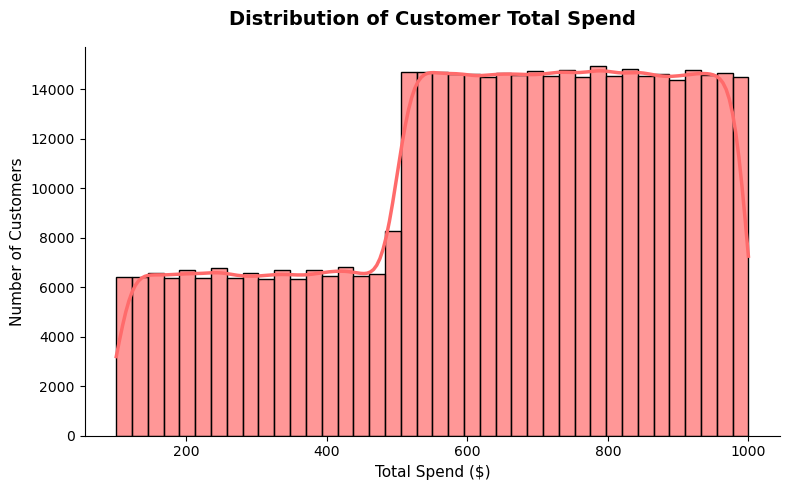

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))

# Histogram with KDE trend line in coral tones
sns.histplot(
    df_clean["Total Spend"],
    bins=40,
    kde=True,
    color="#ff6b6b",
    alpha=0.7,
    line_kws={"color": "#c0392b", "linewidth": 2.5},
    ax=ax
)

# Style
ax.set_title("Distribution of Customer Total Spend", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Total Spend ($)", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)
sns.despine()

plt.tight_layout()
plt.show()

The distribution of customer total spend appears relatively uniform across the observed range, with customer spending values distributed between approximately `$100` and `$1,000`. Unlike many real-world subscription businesses, where revenue distributions tend to be heavily right-skewed (with a small group of high-value customers generating a large share of total revenue), this dataset shows a more balanced spread of spending levels.

This pattern suggests that the dataset may have been generated synthetically or designed for analytical exercises, resulting in a more even distribution of customer spending across the population.

## Revenue by Subscription Type

To better understand how economic value is distributed across the customer base, the next step examines revenue generation across different subscription tiers. By analyzing total revenue and average revenue per customer for each subscription type, it becomes possible to identify which segments contribute most to the platform’s financial performance and whether revenue differences are driven primarily by customer volume or by spending intensity.


In [17]:
revenue_subscription = duckdb.sql("""
SELECT
    "Subscription Type",
    COUNT(*) AS customers,
    SUM("Total Spend") AS total_revenue,
    AVG("Total Spend") AS avg_revenue_per_customer
FROM df_clean
GROUP BY "Subscription Type"
ORDER BY total_revenue DESC
""").df()

revenue_subscription

,Subscription Type,customers,total_revenue,avg_revenue_per_customer
0,Standard,149128,94417746.64,633.132253
1,Premium,148678,94102240.69,632.926463
2,Basic,143026,89916655.39,628.673496


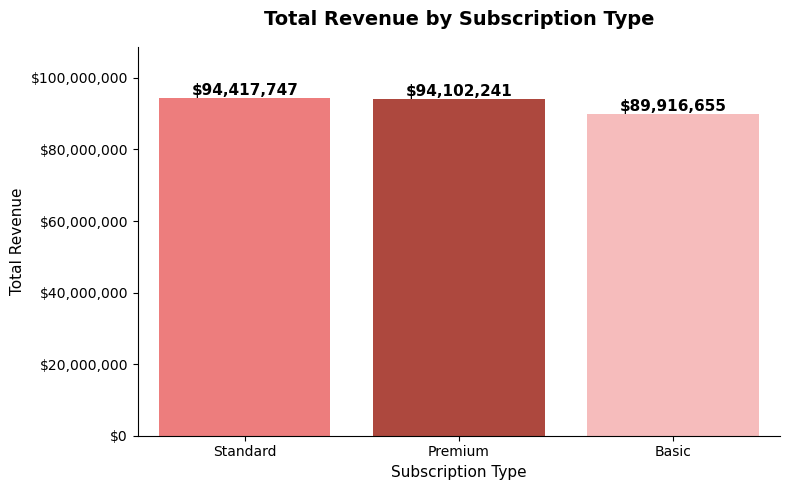

In [18]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(8, 5))

# Barplot in coral tones
sns.barplot(
    data=revenue_subscription,
    x="Subscription Type",
    y="total_revenue",
    hue="Subscription Type",
    palette={"Basic": "#ffb3b3", "Standard": "#ff6b6b", "Premium": "#c0392b"},
    legend=False,
    ax=ax
)

# Format Y axis as dollar amounts
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + (revenue_subscription["total_revenue"].max() * 0.01),
        f"${height:,.0f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Style
ax.set_title("Total Revenue by Subscription Type", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Subscription Type", fontsize=11)
ax.set_ylabel("Total Revenue", fontsize=11)
ax.set_ylim(0, revenue_subscription["total_revenue"].max() * 1.15)
sns.despine()

plt.tight_layout()
plt.show()

The results show that revenue generation is relatively balanced across the three subscription tiers. Standard subscriptions generate the highest total revenue, reaching approximately `$94.4` million, followed closely by Premium subscriptions at `$94.1`million, while Basic subscriptions contribute around `$89.9` million.

This pattern appears to be primarily driven by customer volume rather than meaningful differences in spending behavior. The average revenue per customer remains remarkably similar across tiers, with values around `$628-633`. This suggests that the economic contribution of each subscription tier is largely determined by the number of customers rather than by significantly different spending levels between plans.


## Revenue by Contract Length

In addition to subscription tiers, contract structure can play a significant role in shaping revenue patterns. Different contract lengths may influence both customer commitment and spending behavior.

To further understand the economic contribution of each contract segment, the following analysis examines how total revenue and average revenue per customer vary across contract lengths. This helps identify whether longer commitments are associated with higher revenue generation or whether revenue is evenly distributed across contract structures.


In [19]:
revenue_contract = duckdb.sql("""
SELECT
    "Contract Length",
    COUNT(*) AS customers,
    SUM("Total Spend") AS total_revenue,
    AVG("Total Spend") AS avg_revenue_per_customer
FROM df_clean
GROUP BY "Contract Length"
ORDER BY total_revenue DESC
""").df()

revenue_contract

,Contract Length,customers,total_revenue,avg_revenue_per_customer
0,Annual,177198,1.154793e+08,651.696325
1,Quarterly,176530,1.149963e+08,651.426516
2,Monthly,87104,4.796103e+07,550.618048


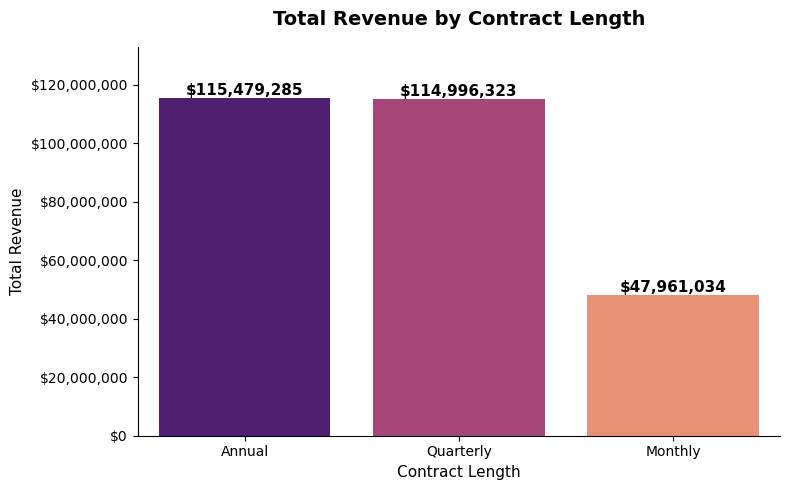

In [41]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(8, 5))

# Barplot in magma palette
sns.barplot(
    data=revenue_contract,
    x="Contract Length",
    y="total_revenue",
    hue="Contract Length",
    palette="magma",
    legend=False,
    ax=ax
)

# Format Y axis as dollar amounts
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + (revenue_contract["total_revenue"].max() * 0.01),
        f"${height:,.0f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Style
ax.set_title("Total Revenue by Contract Length", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Contract Length", fontsize=11)
ax.set_ylabel("Total Revenue", fontsize=11)
ax.set_ylim(0, revenue_contract["total_revenue"].max() * 1.15)
sns.despine()

plt.tight_layout()
plt.savefig("revenue_by_contract.png",dpi=300,bbox_inches="tight")

plt.show()

The analysis reveals that longer contract commitments generate substantially higher total revenue compared to monthly contracts. Annual and quarterly contracts each contribute approximately `$115`million in total revenue, while monthly contracts account for a significantly smaller share at roughly $48 million.

This difference is primarily driven by the number of customers within each contract segment. Both annual and quarterly contracts have roughly twice as many customers as monthly contracts, which explains their larger overall revenue contribution.

In addition to customer volume, average revenue per customer is also higher for longer-term contracts. Annual and quarterly customers generate approximately `$651` per customer on average, compared to about `$551` for monthly customers. This suggests that longer contract commitments are associated with slightly higher spending levels.

These findings align with the earlier churn analysis, where monthly contracts exhibited significantly higher churn rates. Together, the results indicate that longer contractual commitments may contribute not only to improved customer retention but also to more stable and higher-value revenue streams.


## Revenue by Churn Status

To better understand the financial implications of customer churn, it is important to examine how revenue differs between customers who remained with the platform and those who churned.

By comparing total revenue and average spending across churn groups, this analysis helps determine whether churn is concentrated among lower-value customers or if a significant portion of revenue is being generated by customers who eventually leave the platform. Understanding this relationship is critical for assessing the economic impact of churn on the business.


In [21]:
revenue_churn = duckdb.sql("""
SELECT
    Churn,
    COUNT(*) AS customers,
    SUM("Total Spend") AS total_revenue,
    AVG("Total Spend") AS avg_revenue_per_customer
FROM df_clean
GROUP BY Churn
ORDER BY Churn
""").df()

revenue_churn

,Churn,customers,total_revenue,avg_revenue_per_customer
0,0,190833,1.431158e+08,749.953111
1,1,249999,1.353208e+08,541.285528


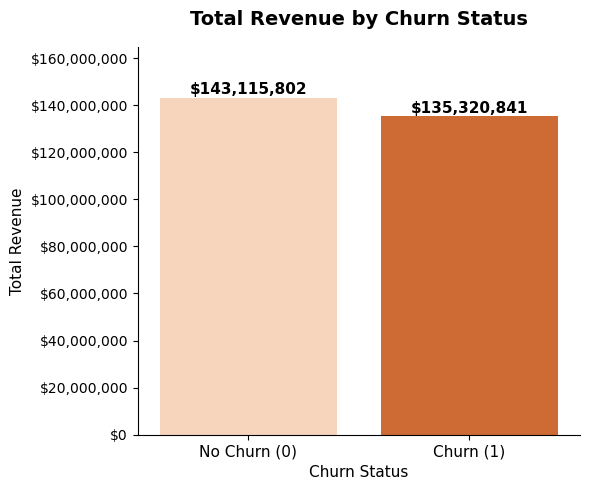

In [22]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(6, 5))

# Barplot in salmon/orange tones
sns.barplot(
    data=revenue_churn,
    x="Churn",
    y="total_revenue",
    hue="Churn",
    palette={0: "#ffd4b3", 1: "#e8621a"},
    legend=False,
    ax=ax
)

# Format Y axis as dollar amounts
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + (revenue_churn["total_revenue"].max() * 0.01),
        f"${height:,.0f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Style
ax.set_title("Total Revenue by Churn Status", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Churn Status", fontsize=11)
ax.set_ylabel("Total Revenue", fontsize=11)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Churn (0)", "Churn (1)"], fontsize=11)
ax.set_ylim(0, revenue_churn["total_revenue"].max() * 1.15)
sns.despine()

plt.tight_layout()
plt.show()

The comparison between churned and retained customers reveals notable differences in revenue contribution. While churned customers represent the larger group in the dataset (approximately 250,000 customers compared to about 191,000 retained customers), their economic value per customer is significantly lower.

Retained customers generate substantially higher average revenue, with an average spend of approximately `$750` per customer, compared to about `$541` among churned customers. Despite the larger number of churned customers, total revenue remains relatively similar between the two groups, with retained customers contributing around `$143` million and churned customers about `$135` million.

This pattern suggests that higher-value customers are more likely to remain with the platform, while churn tends to occur more frequently among lower-spending customers. As a result, although churn affects a large portion of the customer base, the revenue impact may be partially mitigated by the higher spending behavior of retained customers.

# Churn Risk Factors

After evaluating revenue dynamics and the financial exposure associated with customer churn, the next step is to explore potential behavioral factors that may be associated with customer attrition.

This section examines several operational variables—including usage frequency, support calls, payment delay, and last interaction—to identify patterns that may help explain why some customers are more likely to churn than others. Understanding these risk factors can provide valuable insights for developing targeted retention strategies and improving customer engagement.


## Usage Frequency

In [23]:
usage_churn = duckdb.sql("""
SELECT
    Churn,
    COUNT(*) AS customers,
    AVG("Usage Frequency") AS avg_usage_frequency
FROM df_clean
GROUP BY Churn
ORDER BY Churn
""").df()

usage_churn

,Churn,customers,avg_usage_frequency
0,0,190833,16.260552
1,1,249999,15.461658


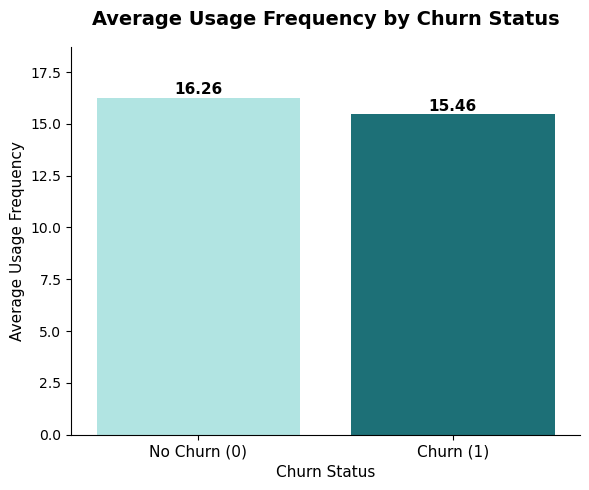

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))

# Barplot in blue-aqua tones
sns.barplot(
    data=usage_churn,
    x="Churn",
    y="avg_usage_frequency",
    hue="Churn",
    palette={0: "#a8edea", 1: "#0e7c86"},
    legend=False,
    ax=ax
)

# Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + (usage_churn["avg_usage_frequency"].max() * 0.01),
        f"{height:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Style
ax.set_title("Average Usage Frequency by Churn Status", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Churn Status", fontsize=11)
ax.set_ylabel("Average Usage Frequency", fontsize=11)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Churn (0)", "Churn (1)"], fontsize=11)
ax.set_ylim(0, usage_churn["avg_usage_frequency"].max() * 1.15)
sns.despine()

plt.tight_layout()
plt.show()

## Support Calls

In [25]:
support_churn = duckdb.sql("""
SELECT
    Churn,
    COUNT(*) AS customers,
    AVG("Support Calls") AS avg_support_calls
FROM df_clean
GROUP BY Churn
ORDER BY Churn
""").df()

support_churn

,Churn,customers,avg_support_calls
0,0,190833,1.586418
1,1,249999,5.144861


## Payment Delay

In [26]:
payment_churn = duckdb.sql("""
SELECT
    Churn,
    COUNT(*) AS customers,
    AVG("Payment Delay") AS avg_payment_delay
FROM df_clean
GROUP BY Churn
ORDER BY Churn
""").df()

payment_churn

,Churn,customers,avg_payment_delay
0,0,190833,10.015500
1,1,249999,15.217729


## Last Interaction

In [27]:
interaction_churn = duckdb.sql("""
SELECT
    Churn,
    COUNT(*) AS customers,
    AVG("Last Interaction") AS avg_last_interaction
FROM df_clean
GROUP BY Churn
ORDER BY Churn
""").df()

interaction_churn

,Churn,customers,avg_last_interaction
0,0,190833,13.008804
1,1,249999,15.604546


## Analysis of Risk Factors

To better understand which behavioral factors are most strongly associated with customer churn, a feature importance analysis was conducted using a Random Forest classification model. 

By examining the importance scores generated by the model, we can determine which operational and behavioral indicators are most closely linked to customer attrition and therefore represent the most relevant areas for potential intervention.

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

features = [
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Last Interaction"
]

X = df_clean[features]
y = df_clean["Churn"]

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
1,Support Calls,0.472162
2,Payment Delay,0.314236
3,Last Interaction,0.114606
0,Usage Frequency,0.098996


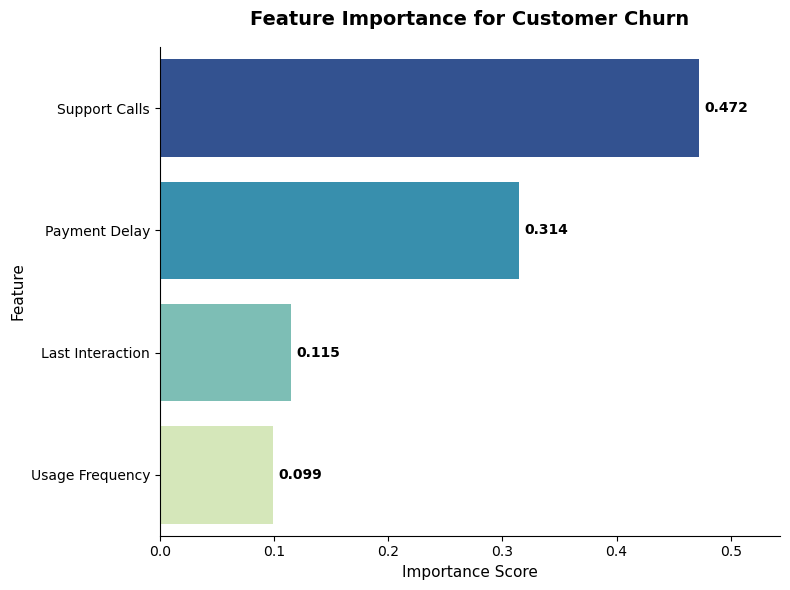

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort by importance for cleaner visualization
importance_sorted = importance.sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))

# Horizontal barplot in aqua/teal tones
sns.barplot(
    data=importance_sorted,
    x="importance",
    y="feature",
    hue="feature",
    palette="YlGnBu_r",
    legend=False,
    ax=ax
)

# Add value labels at the end of each bar
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + (importance_sorted["importance"].max() * 0.01),
        p.get_y() + p.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Style
ax.set_title("Feature Importance for Customer Churn", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
ax.set_xlim(0, importance_sorted["importance"].max() * 1.15)
sns.despine()

plt.tight_layout()

plt.savefig("feature_importance_churn.png",dpi=300,bbox_inches="tight")
plt.savefig("feature_importance_churn_p.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

The feature importance analysis highlights **support-related interactions as the strongest predictor of customer churn**. Support Calls account for nearly half of the model's predictive importance (47%), indicating that customers who frequently contact support are substantially more likely to churn. This suggests that unresolved service issues or repeated customer frustrations may be a major driver of customer attrition.

Payment Delay emerges as the second most important factor (31%), pointing to financial friction as another key contributor to churn. Customers who experience recurring payment delays may be less committed to the service or may encounter billing-related obstacles that increase the likelihood of disengagement.

In contrast, engagement-related indicators such as Last Interaction (11%) and Usage Frequency (10%) appear to have a comparatively smaller influence on churn within this dataset. While lower engagement is associated with churn, operational and financial frictions appear to play a more decisive role in driving customer attrition.

# Revenue at Risk from Customer Churn

While previous analyses compared revenue patterns across churn groups, it is also important to quantify the overall financial exposure associated with customer churn.

Revenue at risk represents the portion of total revenue generated by customers who eventually churned. Estimating this value provides a clearer understanding of the potential financial impact of customer attrition and highlights the importance of retention strategies in protecting long-term revenue stability.


In [30]:
revenue_risk = duckdb.sql("""
SELECT
    SUM("Total Spend") AS total_revenue,
    SUM(CASE WHEN Churn = 1 THEN "Total Spend" ELSE 0 END) AS churned_revenue,
    SUM(CASE WHEN Churn = 0 THEN "Total Spend" ELSE 0 END) AS retained_revenue,
    SUM(CASE WHEN Churn = 1 THEN "Total Spend" ELSE 0 END) * 1.0 
        / SUM("Total Spend") AS revenue_at_risk_pct
FROM df_clean
""").df()

revenue_risk

,total_revenue,churned_revenue,retained_revenue,revenue_at_risk_pct
0,2.784366e+08,135320840.6,1.431158e+08,0.486002


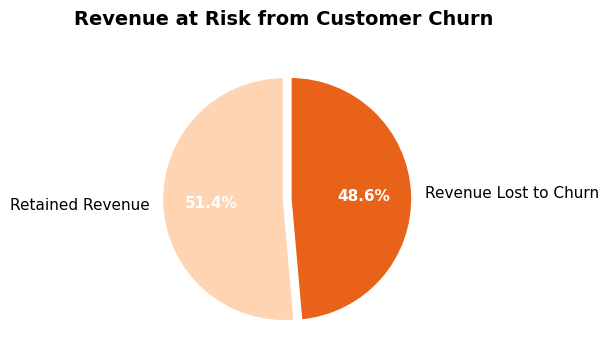

In [38]:
fig, ax = plt.subplots(figsize=(6, 6))

labels = ["Retained Revenue", "Revenue Lost to Churn"]
values = [
    revenue_risk["retained_revenue"][0],
    revenue_risk["churned_revenue"][0]
]
colors = ["#ffd4b3", "#e8621a"]
explode = [0, 0.05]  # Slightly separate the churn slice for emphasis

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    explode=explode,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

# Style labels
for text in texts:
    text.set_fontsize(11)

# Style percentage labels
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

ax.set_title("Revenue at Risk from Customer Churn", fontsize=14, fontweight="bold", pad=16)

plt.tight_layout()
plt.savefig("revenue_at_risk.png",dpi=300,bbox_inches="tight")
plt.savefig("revenue_at_risk_p.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

The revenue at risk analysis reveals that a substantial portion of the platform’s revenue is associated with customers who eventually churned. Out of approximately `$278` million in total revenue, about `$135` million—representing roughly 48.6% of total revenue—comes from customers who ultimately left the platform.

While retained customers still generate slightly more total revenue overall (around `$143` million), the fact that nearly half of total revenue is linked to churned customers highlights the significant financial exposure associated with customer attrition.

This finding reinforces the importance of effective retention strategies. Even modest improvements in customer retention could have a meaningful impact on long-term revenue stability, given the large share of revenue currently tied to customers who churn.


# Executive Summary

## Context

This analysis was conducted to understand the drivers of customer churn and its financial implications for the platform. The objective was to examine how contract structure, customer behavior, and operational factors relate to churn risk and revenue generation.

Using the available dataset, the analysis explored customer segmentation patterns, revenue distribution across subscription tiers and contract structures, behavioral risk factors associated with churn, and the proportion of revenue exposed to customer attrition.

---

## Findings

Several key insights emerge from the analysis.

First, **contract structure appears to play an important role in customer retention**. Customers on monthly contracts exhibit substantially higher churn rates compared with those on quarterly or annual plans, suggesting that shorter commitments may increase customer mobility and reduce retention stability.

Second, **total revenue is largely driven by the number of customers rather than by differences in spending across subscription tiers**. Average revenue per customer remains remarkably consistent across plans, with values around `$628-633`. This indicates that growth in revenue depends primarily on customer volume rather than pricing differences between tiers.

Third, **longer contract commitments generate significantly higher total revenue**. Annual and quarterly contracts each contribute approximately `$115`million in total revenue, while monthly contracts generate roughly `$48` million. This difference is primarily explained by the larger number of customers within longer-term contract segments.

Fourth, **retained customers generate higher economic value**. On average, retained customers spend approximately `$750` compared with about `$541` among churned customers. Despite the larger number of churned customers, total revenue remains relatively balanced between the two groups due to the higher spending behavior of retained users.

Fifth, **a significant portion of revenue is associated with customers who eventually churn**. Approximately `$135` million—representing about **48.6% of total revenue**—comes from customers who ultimately leave the platform, highlighting a substantial level of financial exposure.

Finally, the **feature importance analysis identifies operational friction as the strongest predictor of churn**. Support Calls account for nearly half of the model's predictive importance (47%), followed by Payment Delay (31%). Engagement indicators such as Usage Frequency and Last Interaction appear to play a comparatively smaller role in explaining churn behavior.

---

## Implications

These findings suggest several strategic opportunities to reduce churn and protect revenue.

First, given the strong relationship between support interactions and churn, a deeper investigation into **customer support requests** is recommended. Analyzing support tickets and categorizing the most frequent issues could help determine whether churn is primarily driven by product-related problems, service quality issues, or unresolved customer concerns.

Second, the high churn rates observed among **monthly contract customers** suggest that this segment warrants targeted analysis. Further investigation could examine whether customers who frequently contact support are disproportionately represented among monthly subscribers. If confirmed, this segment may benefit from proactive retention strategies or early-warning churn monitoring.

Third, the results indicate that **longer contract commitments provide greater revenue stability and retention**. Encouraging customers to transition from monthly plans to quarterly or annual subscriptions—through pricing incentives, loyalty benefits, or bundled offerings—may help improve customer lifetime value and reduce churn risk.

---

## Limitations

Several limitations should be considered when interpreting the results.

First, the dataset used for this analysis appears to be **synthetic**, which may limit the realism of certain behavioral patterns. Some variables—such as customer tenure and revenue distribution—display relatively uniform structures that may not fully reflect real-world variability.

Second, the analysis is based on **observational data**, meaning that relationships identified between variables and churn represent correlations rather than causal relationships.

Finally, while the feature importance model identifies variables associated with churn, it does not capture the full complexity of customer decision-making processes. Additional data—such as detailed support ticket categories, product usage behavior, or customer satisfaction metrics—would likely provide deeper insight into the underlying causes of customer attrition.
